# From notebook output to an AI image question

Run this scenario cell by cell in a disposable JupyterLab project with a live Python kernel and selected ChatGPT connection. A generated red output is exported, previewed, cropped, optionally saved, and attached to one question only after you click **Attach image**. The preflight question checks that no image was sent before that click. Wait for each browser receipt before its inspection or dependent call, and run the final image question yourself.


## Make a disposable notebook output


In [1]:
from io import BytesIO
import hashlib
from pathlib import Path
from PIL import Image as PILImage
from IPython.display import display, Image
from nbinlineai.tools import (list_outputs, export_output, open_media, close_media, crop_image, save_media, attach_media, release_media, operation_status)
source_image = PILImage.new('RGB', (8, 8), (212, 64, 47))
encoded = BytesIO(); source_image.save(encoded, format='PNG')
PNG_BYTES = encoded.getvalue()
print('Disposable 8x8 output image ready; no file saved.')


Disposable 8x8 output image ready; no file saved.


In [2]:
display(Image(data=PNG_BYTES))


## Export the existing output

Run the list call, then its inspection cell after the browser answers. Export its exact output ID and revision into owned memory. Neither step reruns the image cell or creates a file.


In [3]:
listing = list_outputs('integration-output')
listing


BrowserReceipt(operation_id=None, status='running')

In [4]:
print(listing.status, listing.error)
output_ref = listing.result['outputs'][0] if listing.status == 'completed' else None
print('Output reference:', {key: output_ref.get(key) for key in ('cell_id', 'output_id', 'revision', 'mime_types')} if output_ref else None)


completed None
Output reference: {'cell_id': 'integration-output', 'output_id': '37760cde90508c4c6b6f079f6d9919fc', 'revision': 0, 'mime_types': ['image/png', 'text/plain']}


Use &`list_outputs` for cell ID `integration-output`. Report only its immediate operation ID/state; do not invent an output ID or MIME type before the later status question.


Use &`operation_status` on the preceding AI `list_outputs` operation ID after completion. Report actual output ID, revision, and MIME type of the generated red image; do not rerun that cell.


In [5]:
assert output_ref, 'Wait for list_outputs and rerun its inspection cell.'
exported = export_output(output_ref['cell_id'], output_ref['output_id'], output_ref['revision'])
exported


BrowserReceipt(operation_id=None, status='running')

In [6]:
print(exported.status, exported.error)
if exported.status == 'completed':
    assert exported.result.size == (8, 8)
    assert exported.result.getpixel((0, 0))[:3] == (212, 64, 47)
    print('Exported memory hash:', exported.media['sha256'])
    exported_media_ref = exported.media


completed None
Exported memory hash: 269661e8dbcb389941d2a1c41323776fac18a1ee3a08e9582a6c485291b53a88


## Preview the exported memory image

Opening a preview does not change the output or attach it to a question. Inspect its receipt in a later cell.


In [7]:
assert exported.status == 'completed', 'Wait for export_output first.'
preview = open_media(exported.media)
preview


BrowserReceipt(operation_id=None, status='running')

In [8]:
print(preview.status, preview.result, preview.error)


completed {'preview_id': '9433645d5368c286385cc5face7b4c74', 'kind': 'image', 'width': 8, 'height': 8} None


## Make a new four-pixel-square derivative

The crop remains in owned memory and leaves the eight-pixel source unchanged. The later inspection checks actual decoded pixels and reports the exact encoded PNG hash.


In [9]:
crop = crop_image(exported.media, 0, 0, 4, 4)
crop


BrowserReceipt(operation_id=None, status='running')

completed None
Derivative memory hash: b8927261e3dc400dae17dced7b23227990528469c73c3546d89a8f20d53d88af


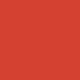

In [10]:
print(crop.status, crop.error)
if crop.status == 'completed':
    assert crop.result.size == (4, 4)
    assert crop.result.getpixel((0, 0))[:3] == (212, 64, 47)
    assert exported.result.size == (8, 8)
    print('Derivative memory hash:', crop.media['sha256'])
    crop_media_ref = crop.media
    display(crop.result.resize((80, 80)))


## Save the derivative as a separate file

This call writes a new server-root-relative PNG and keeps the in-memory derivative for the question. Its later cleanup removes only the generated saved path.


In [11]:
assert crop.status == 'completed', 'Wait for crop_image first.'
saved = save_media(crop.media, save_to='auto')
saved


BrowserReceipt(operation_id=None, status='running')

In [12]:
print(saved.status, saved.media, saved.error)
if saved.status == 'completed':
    assert saved.media['sha256'] == crop.media['sha256']
    assert hashlib.sha256((Path.cwd() / saved.media['path']).read_bytes()).hexdigest() == crop.media['sha256']
    import json
    sidecar_path = Path.cwd() / saved.media['sidecar_path']
    assert sidecar_path.is_file()
    provenance = json.loads(sidecar_path.read_text())
    assert provenance['transform'] == 'crop_image'
    assert provenance['source_sha256'] == exported.media['sha256']
    assert provenance['output_sha256'] == crop.media['sha256']
    assert provenance['parameters'] == {'x': 0, 'y': 0, 'width': 4, 'height': 4}
    print('Saved path:', saved.media['path'])
    print('Sidecar path:', saved.media['sidecar_path'])


completed {'media_id': 'VlolRPoxt7b_CPVhFosQ6HKrStdGohBc', 'mime_type': 'image/png', 'bytes': 109, 'sha256': 'b8927261e3dc400dae17dced7b23227990528469c73c3546d89a8f20d53d88af', 'expires_at': 1790678597.995946, 'source_sha256': '269661e8dbcb389941d2a1c41323776fac18a1ee3a08e9582a6c485291b53a88', 'transform': 'crop_image', 'width': 4, 'height': 4, 'sidecar_path': 'media/capture-e811c877e89cf03f.png.json', 'path': 'media/capture-e811c877e89cf03f.png'} None
Saved path: media/capture-e811c877e89cf03f.png
Sidecar path: media/capture-e811c877e89cf03f.png.json


## Ask without an attachment

Run this question with the selected ChatGPT connection before the attachment step. The generated output and preview alone do not send a native image to the model.


Before I confirm any image attachment, do you receive a native image from this notebook? Answer briefly.


## Confirm only the derivative for the next question

Run the call, click **Attach image** in the visible confirmation, then rerun the inspection cell until the receipt is complete. Confirmation changes only the identified question; it never runs it.


In [ ]:
assert crop.status == 'completed', 'Wait for the crop first.'
attached = attach_media(crop.media, 'integration-question', detail='auto')
attached


In [ ]:
print(attached.status, attached.result, attached.error)


## Confirm, then ask about the image

Open context preview to check the confirmed image indicator, then explicitly run this question with the selected ChatGPT connection. The model receives the four-pixel crop as a native image item rather than base64 in tool text.


What is the visible color in the four-pixel-square image I explicitly attached?


## Clean up owned memory and optional file

Run after the question. The first cell closes the preview and releases managed bytes. The final cell removes only this example’s generated saved path, if the optional save ran.


In [13]:
closed_preview = close_media(preview.result['preview_id']) if preview.status == 'completed' else None
released_export = release_media(exported.media['media_id']) if exported.status == 'completed' else None
released_crop = release_media(crop.media['media_id']) if crop.status == 'completed' else None
print('Cleanup requested; inspect the receipts later.')


Cleanup requested; inspect the receipts later.


In [14]:
print('Preview:', closed_preview.status if closed_preview else 'none')
print('Export:', released_export.status if released_export else 'none')
print('Crop:', released_crop.status if released_crop else 'none')


Preview: completed
Export: completed
Crop: completed


In [15]:
if 'saved' in globals() and saved.status == 'completed':
    saved_path = Path.cwd() / saved.media['path']
    assert saved_path.is_file()
    sidecar_path = Path.cwd() / saved.media['sidecar_path']
    assert sidecar_path.is_file()
    saved_path.unlink()
    sidecar_path.unlink()
    print('Optional generated file and sidecar removed:', not saved_path.exists() and not sidecar_path.exists())
else:
    print('No optional file was saved.')


Optional generated file and sidecar removed: True
